# Phase 6: Feature Engineering (RFM Analysis)

This notebook continues the pipeline from `02_EDA.ipynb`. The cleaned dataset is reloaded
and the `Revenue` feature is recreated (`Quantity * Price`) before building RFM (Recency,
Frequency, Monetary) features at the customer level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv", parse_dates=["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["Price"]

print("Loaded cleaned dataset:", df.shape)
df.head()

Loaded cleaned dataset: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# Phase 6: Feature Engineering (RFM Analysis)

## Objective

Customer segmentation based solely on raw transaction data is difficult because each customer may have multiple purchases over time.

To summarize customer purchasing behavior, RFM Analysis is performed.

RFM stands for:

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of unique purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These three metrics provide a concise representation of customer value and form the foundation for customer segmentation and retention analysis.

In [3]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

analysis_date

C:\Users\HP\AppData\Local\Temp\ipykernel_38740\1466368544.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)


Timestamp('2011-12-10 12:50:00')

In [4]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer ID")
      .agg({
          "InvoiceDate": lambda x: (analysis_date - x.max()).days,
          "Invoice": "nunique",
          "Revenue": "sum"
      })
)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

rfm.shape

C:\Users\HP\AppData\Local\Temp\ipykernel_38740\2907097823.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)


(5878, 3)

# Phase 6.2: Exploring RFM Features

## Objective

Before applying K-Means clustering, the RFM features must be analyzed to understand their distribution and identify potential outliers.

Since K-Means is a distance-based algorithm, features with different scales or extreme values can significantly influence the clustering results.

This analysis helps determine whether transformations or feature scaling are required before model training.

In [5]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [6]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

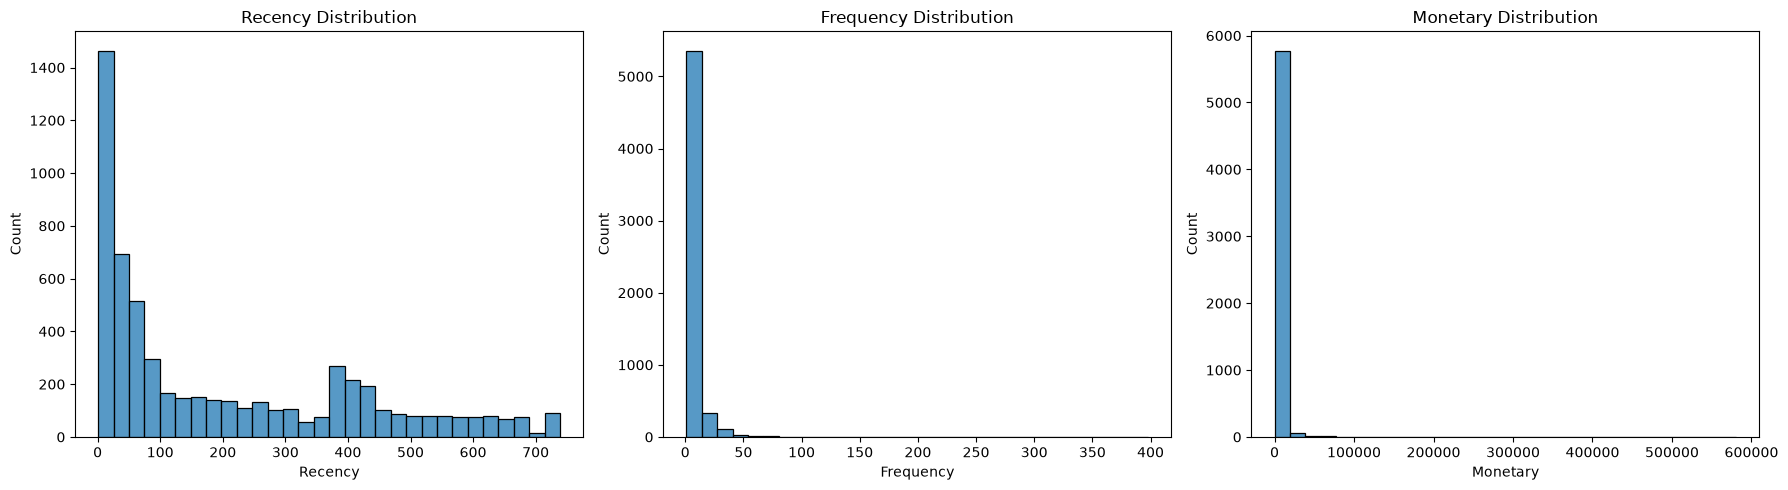

In [7]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(rfm["Recency"], ax=axes[0], bins=30)
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], ax=axes[1], bins=30)
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], ax=axes[2], bins=30)
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

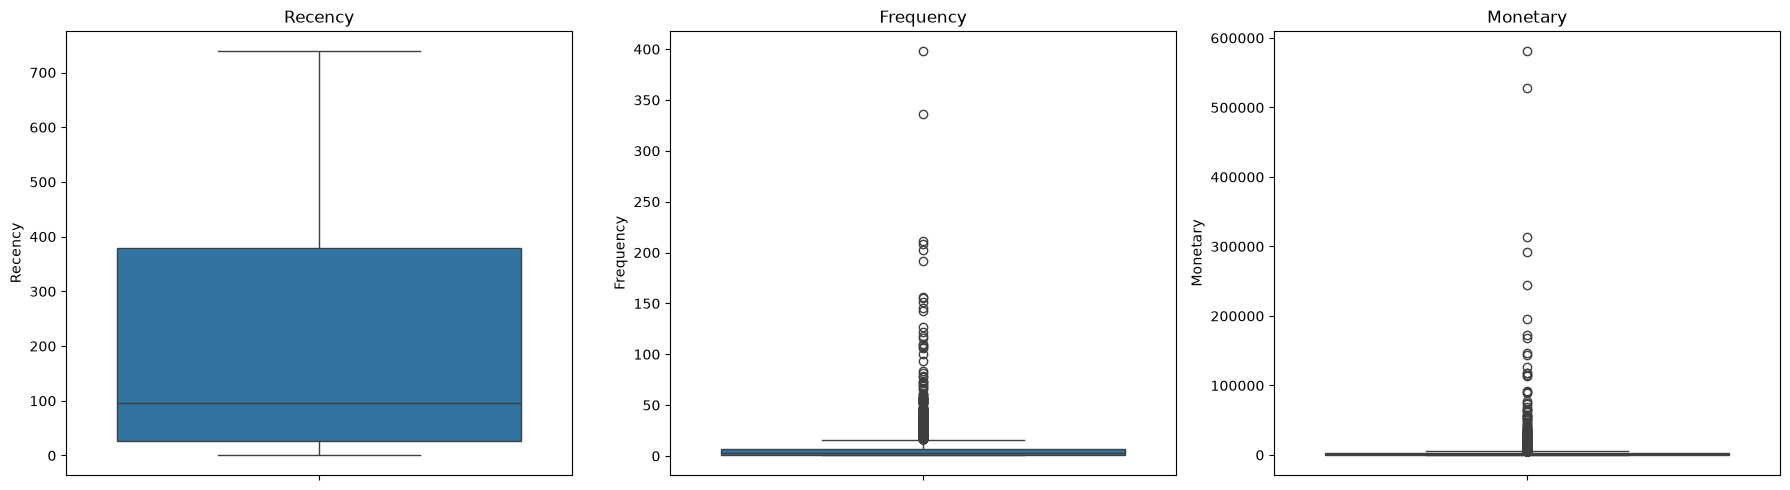

In [8]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.boxplot(y=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.boxplot(y=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

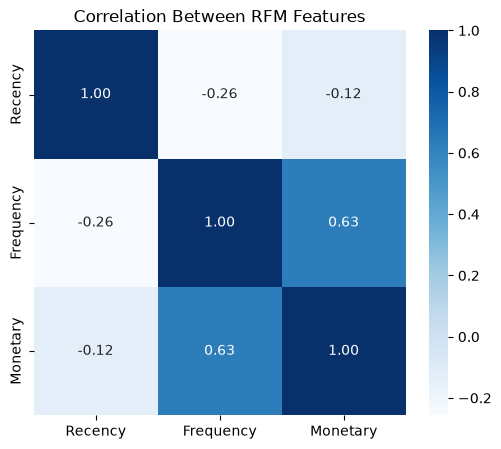

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between RFM Features")

plt.show()

## Business Questions

Before clustering, we investigate the following:

- Are customers generally recent or inactive?
- Do most customers purchase frequently or only occasionally?
- Is customer spending evenly distributed or dominated by a small group of high-value customers?
- Are there extreme outliers that could affect clustering?
- How strongly are the RFM features related to one another?

The answers will determine the preprocessing steps required before applying K-Means.

# Phase 6.3: Data Transformation

## Objective

The RFM features exhibit highly skewed distributions and contain extreme values, particularly for Frequency and Monetary.

Since K-Means clustering relies on Euclidean distance, features with large scales can dominate the clustering process.

To improve clustering quality:

- A logarithmic transformation is applied to reduce skewness.
- Standardization is performed to ensure all features contribute equally during clustering.

In [10]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,5.789960,2.564949,11.258774
12347.0,1.098612,2.197225,8.501578
12348.0,4.330733,1.791759,7.611051
12349.0,2.995732,1.609438,8.396085
12350.0,5.739793,0.693147,5.815324


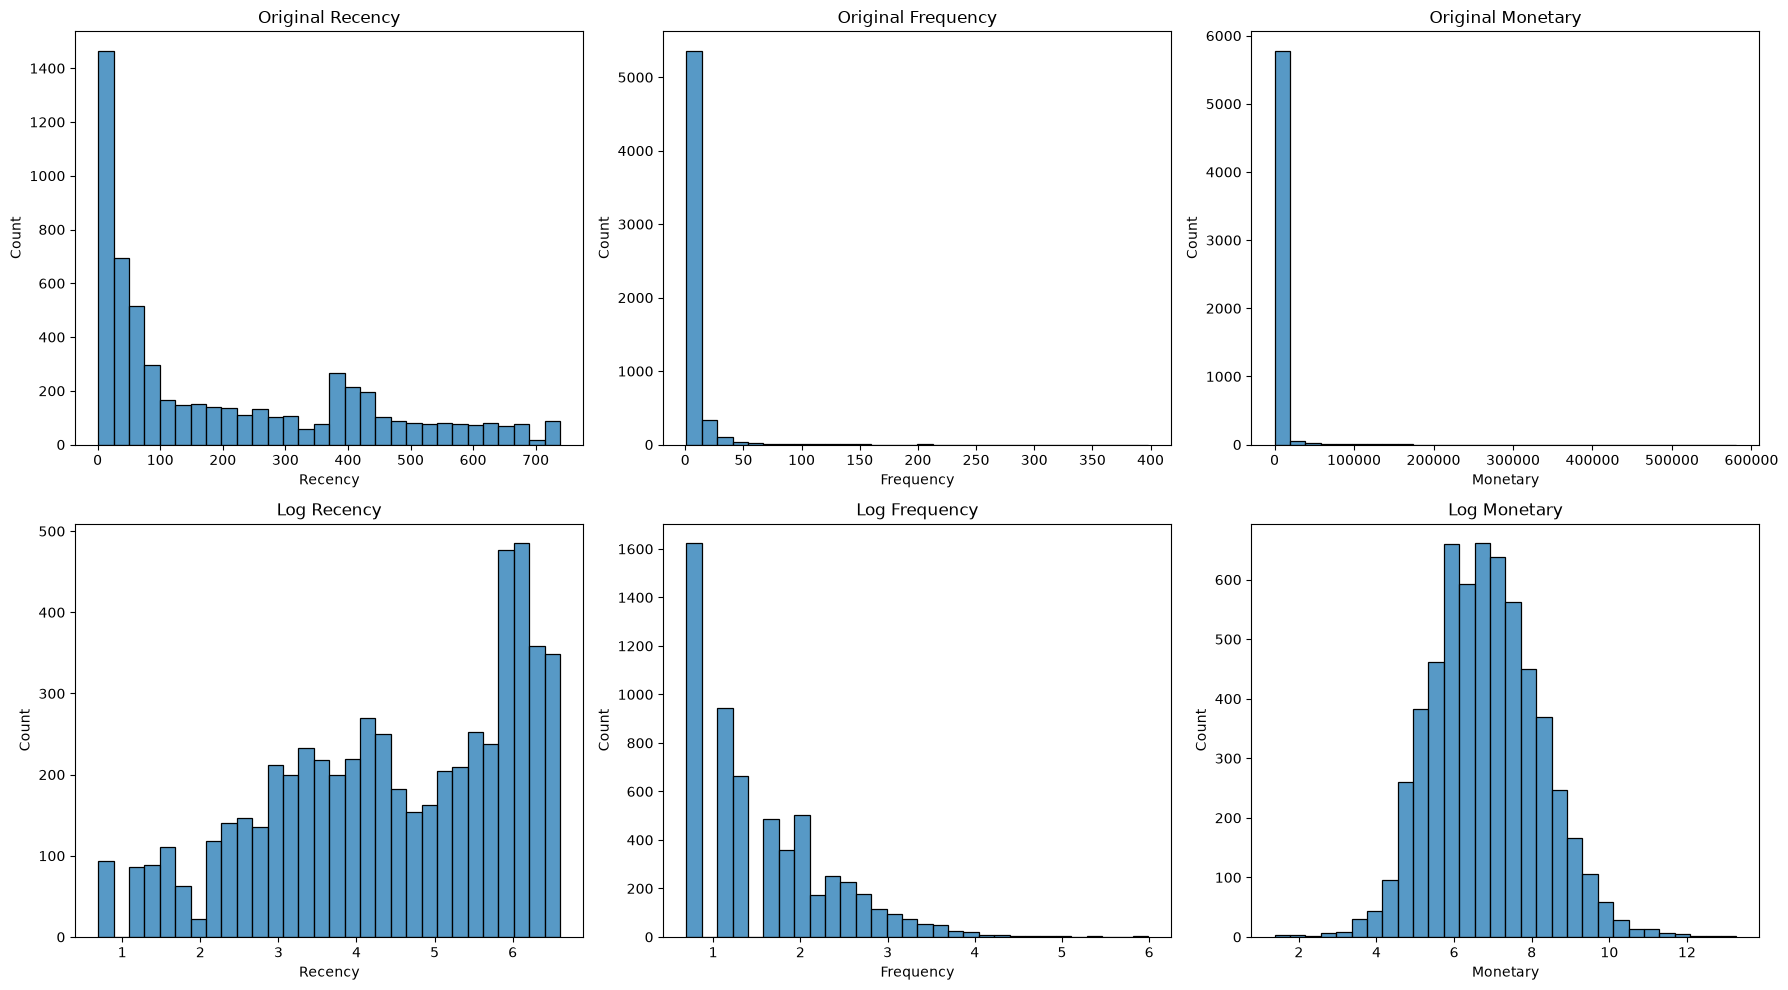

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Original
sns.histplot(rfm["Recency"], bins=30, ax=axes[0,0])
axes[0,0].set_title("Original Recency")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[0,1])
axes[0,1].set_title("Original Frequency")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[0,2])
axes[0,2].set_title("Original Monetary")

# Log transformed
sns.histplot(rfm_log["Recency"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Log Recency")

sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Log Frequency")

sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[1,2])
axes[1,2].set_title("Log Monetary")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [13]:
rfm_scaled[:5]

array([[ 0.85670058,  1.25449595,  3.20621937],
       [-2.15197903,  0.80016603,  1.21599349],
       [-0.07913835,  0.29920733,  0.57318471],
       [-0.93530818,  0.07394609,  1.13984551],
       [ 0.82452706, -1.05814595, -0.72302406]])

## Save RFM Features & Scaler

The engineered RFM table and the fitted `StandardScaler` are persisted so that
`04_Customer_Segmentation.ipynb` can rebuild the exact same scaled feature matrix
without repeating the log-transform / scaling steps above.

In [14]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump(scaler, "../models/scaler.pkl")
rfm.to_csv("../data/rfm_features.csv")

print("Saved scaler -> ../models/scaler.pkl")
print("Saved RFM features -> ../data/rfm_features.csv")

Saved scaler -> ../models/scaler.pkl
Saved RFM features -> ../data/rfm_features.csv
